In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt
import warnings
import os
import subprocess

warnings.simplefilter(action="ignore", category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 2

sc.settings.set_figure_params(dpi=80)

In [2]:
adata = sc.read_h5ad('/home/mdiaz/HCC_project/MERGED_adata/scvi_integrated.h5ad')
adata

AnnData object with n_obs × n_vars = 159925 × 19916
    obs: 'Patient', 'DX', 'Sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'doublet', 'CellType', 'Batch', 'predicted', 'transfer_score', 'dataset', 'CellType_harmonized', 'leiden_r3'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_r3', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [3]:
def add_condition_from_dx(ad):
    # Normaliza DX (maneja NAs)
    dx = ad.obs["DX"].astype(str).str.strip().str.lower().fillna("")

    # Reglas solicitadas:
    # - "adjacent tissue" -> Diseased (HCC)
    # - "tumor tissue"    -> Diseased (HCC)
    # - "healthy"         -> Healthy
    is_diseased = dx.str.contains(r"\badjacent tissue\b") | dx.str.contains(r"\btumou?r tissue\b")
    is_healthy  = dx.str.fullmatch(r"healthy")

    vals = np.where(is_diseased, "Diseased (HCC)",
            np.where(is_healthy, "Healthy", "Unknown"))

    ad.obs["Condition"] = pd.Series(
        pd.Categorical(vals, categories=["Healthy", "Diseased (HCC)", "Unknown"], ordered=True),
        index=ad.obs_names
    )

    # Si no habrá 'Unknown', limpia categorías
    if "Unknown" not in ad.obs["Condition"].values:
        ad.obs["Condition"] = ad.obs["Condition"].cat.remove_unused_categories()
        ad.obs["Condition"] = ad.obs["Condition"].cat.set_categories(
            ["Healthy", "Diseased (HCC)"], ordered=True
        )

# Aplica
add_condition_from_dx(adata)
try:
    add_condition_from_dx(adata_deg)
except NameError:
    pass

# Verificación rápida
print(adata.obs["Condition"].value_counts(dropna=False))
try:
    print(adata_deg.obs["Condition"].value_counts(dropna=False))
except Exception:
    pass

Condition
Healthy           119154
Diseased (HCC)     40771
Name: count, dtype: int64


In [4]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Configuración editable ===
CELLTYPE_KEY = "CellType_harmonized"
COND_KEY     = "Condition"
COND_GROUP   = "Diseased (HCC)"      # grupo cuyo ranking usaremos (vs Healthy)
TOP_N_GENES  = 10
OUT_PNG      = "/home/mdiaz/HCC_project/MERGED_adata/figures/violins_byCellType_from_conditionDE.png"

# (opcional) limita los tipos si la figura es muy ancha; None = todos
CELLTYPES_TO_SHOW = None
# CELLTYPES_TO_SHOW = ["Hepatocyte","Malignant cell","Cholangiocyte","Fibroblast",
#                      "Tumor-associated macrophage (TAM)","Endothelial VWF",
#                      "Tumor endothelial cell (TEC)","T cells","NK cells","B cells","Plasma cell"]

# --- 0) Sanitizar columnas ---
adata.obs[CELLTYPE_KEY] = adata.obs[CELLTYPE_KEY].astype("category")
adata.obs[COND_KEY]     = adata.obs[COND_KEY].astype("category")

# Mantén solo Healthy / Diseased
adata = adata[adata.obs[COND_KEY].isin(["Healthy","Diseased (HCC)"])].copy()
adata.obs[COND_KEY] = adata.obs[COND_KEY].cat.set_categories(["Healthy","Diseased (HCC)"], ordered=True)

# Limitar tipos si se indicó
if CELLTYPES_TO_SHOW is not None:
    adata = adata[adata.obs[CELLTYPE_KEY].isin(CELLTYPES_TO_SHOW)].copy()
    adata.obs[CELLTYPE_KEY] = adata.obs[CELLTYPE_KEY].cat.remove_unused_categories()

# --- 1) Capa normalizada+log para DE y plots (si no existe) ---
if "log1p_norm" not in adata.layers:
    tmp = adata.copy()
    sc.pp.normalize_total(tmp, target_sum=1e4)
    sc.pp.log1p(tmp)
    adata.layers["log1p_norm"] = tmp.X
    del tmp

# --- 2) DE por condición (si falta en .uns) ---
if "wilcoxon_condition" not in adata.uns:
    sc.tl.rank_genes_groups(
        adata,
        groupby=COND_KEY,
        groups=[COND_GROUP],
        reference="Healthy",
        method="wilcoxon",
        layer="log1p_norm",
        key_added="wilcoxon_condition",
    )

# --- 3) Top genes desde la DE por condición ---
def get_top_genes_from_rgg(ad, key, group, topn=10):
    d = ad.uns[key]
    names = list(d["names"][group].tolist())
    if "pvals_adj" in d:
        order = np.argsort(np.array(d["pvals_adj"][group]))
        names = [names[i] for i in order]
    elif "scores" in d:
        order = np.argsort(-np.array(d["scores"][group]))
        names = [names[i] for i in order]
    # únicos y top-n
    return list(dict.fromkeys(names))[:topn]

genes_top = get_top_genes_from_rgg(adata, "wilcoxon_condition", COND_GROUP, TOP_N_GENES)
print(f"[INFO] Genes top ({COND_GROUP} vs Healthy):", genes_top)

# --- 4) Agrupar por tipo celular *dentro* de cada condición (dos violines por tipo) ---
ad = adata.copy()
ad.obs["CTxCond"] = (ad.obs[CELLTYPE_KEY].astype(str) + " | " + ad.obs[COND_KEY].astype(str)).astype("category")

# Orden categorías: para cada tipo, Healthy primero luego Diseased
cts = list(ad.obs[CELLTYPE_KEY].cat.categories)
ordered_pairs = []
for ct in cts:
    sub = ad.obs.loc[ad.obs[CELLTYPE_KEY] == ct, COND_KEY].unique().tolist()
    if "Healthy" in sub:        ordered_pairs.append(f"{ct} | Healthy")
    if "Diseased (HCC)" in sub: ordered_pairs.append(f"{ct} | Diseased (HCC)")
ad.obs["CTxCond"] = ad.obs["CTxCond"].cat.set_categories(ordered_pairs, ordered=True)


normalizing counts per cell
    finished (0:00:00)
ranking genes
    finished (0:09:29)
[INFO] Genes top (Diseased (HCC) vs Healthy): ['SEM1', 'PKM', 'COX6A1', 'TTC3', 'PEPD', 'CXCL8', 'RPS11', 'ATP5PF', 'SDHD', 'GSTO1']


In [5]:
import pandas as pd

# Solo las dos correcciones necesarias
rename_map = {
    "Hep": "Hepatocytes",
    "CDCs": "Conventional dendritic cell",
}

# Aplica el mapeo
adata.obs["CellType_harmonized"] = (
    adata.obs["CellType_harmonized"]
    .astype(str)
    .replace(rename_map)
    .astype("category")
)

# Elimina categorías antiguas (sin inplace)
adata.obs["CellType_harmonized"] = (
    adata.obs["CellType_harmonized"].cat.remove_unused_categories()
)

# Verifica resultado
print("Categorías finales:", list(adata.obs["CellType_harmonized"].cat.categories))


Categorías finales: ['B cells', 'Basophils', 'CAF', 'Cholangiocytes', 'Conventional dendritic cell', 'Endothelial cells', 'Fibroblasts', 'Hepatocytes', 'Macrophages', 'Malignant_cells', 'Monocytes', 'NK cells', 'NK-TR-CD160', 'Neutrophils', 'Plasma cells', 'T cells', 'TAMs', 'TECs', 'cDCs', 'pDCs']


In [6]:
# Borrar el dendrograma viejo si existe
if "dendrogram_CellType_harmonized" in adata.uns:
    del adata.uns["dendrogram_CellType_harmonized"]

# Recalcular con las nuevas categorías ya corregidas
sc.tl.dendrogram(
    adata,
    groupby="CellType_harmonized",
    use_rep="X_pca",  # o "X_scVI" si prefieres esa representación latente
    n_pcs=50
)

print("[INFO] Dendrograma recalculado para CellType_harmonized")


Storing dendrogram info using `.uns['dendrogram_CellType_harmonized']`
[INFO] Dendrograma recalculado para CellType_harmonized


categories: B cells, Basophils, CAF, etc.
var_group_labels: Diseased (HCC)


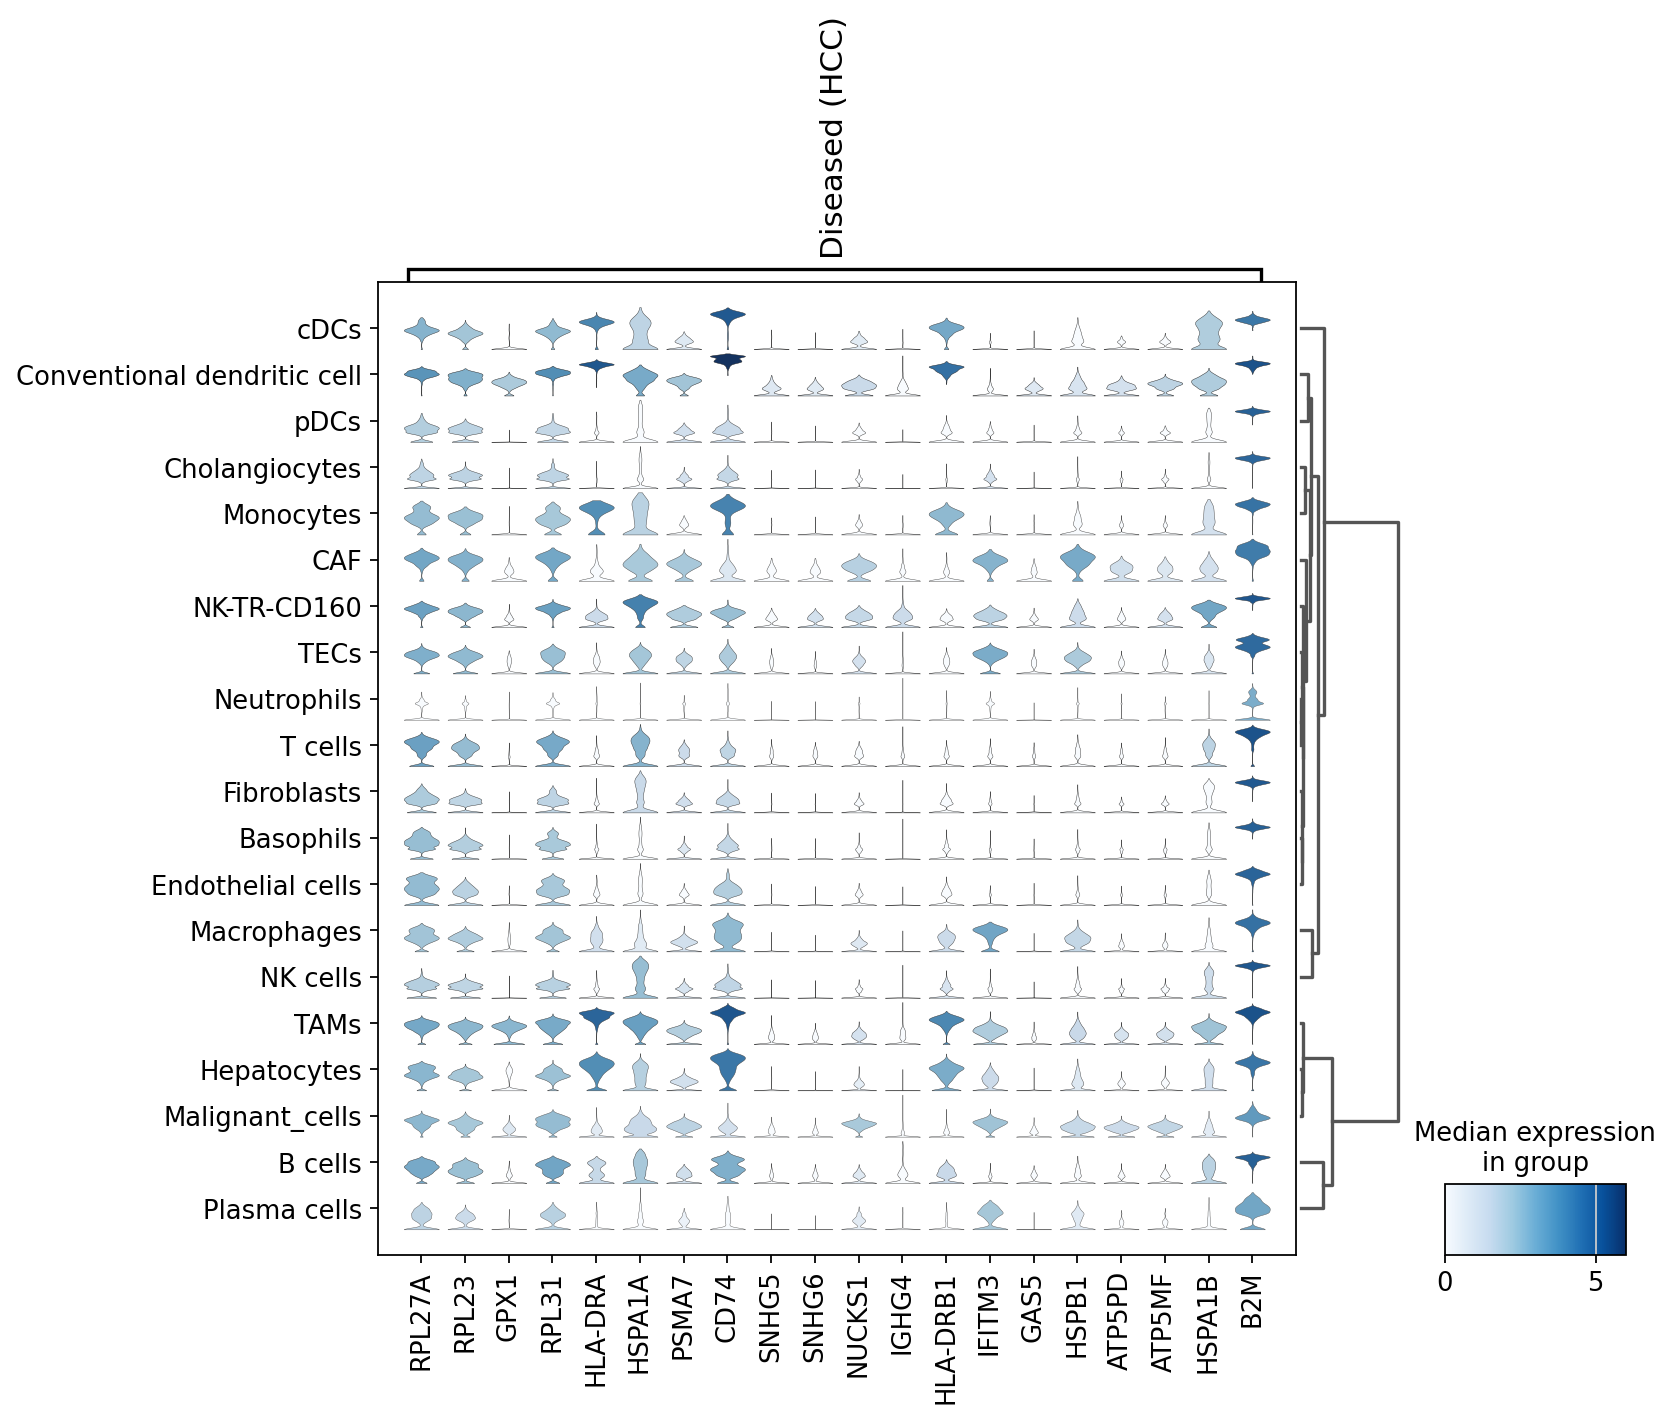

In [7]:
sc.pl.rank_genes_groups_stacked_violin(
    adata,
    key="wilcoxon_condition",
    groupby="CellType_harmonized",
    n_genes=20,
    layer="log1p_norm",
    figsize=(10,8),
    save="_stacked_violin.pdf"
)


In [9]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# ===== Configuración =====
CELLTYPE_KEY = "CellType_harmonized"
COND_KEY     = "Condition"
DISEASED     = "Diseased (HCC)"
HEALTHY      = "Healthy"
TOPK         = 5
OUT_PNG      = "/home/mdiaz/HCC_project/MERGED_adata/figures/stacked_violin_top5_per_celltype.png"

# (opcional) limitar a ciertos tipos si hay demasiados
CELLTYPES_TO_SHOW = None
# CELLTYPES_TO_SHOW = ["Hepatocytes","Malignant cells","Cholangiocyte","Fibroblast",
#                      "Tumor-associated macrophage (TAM)","Endothelial VWF",
#                      "Tumor endothelial cell (TEC)","T cells","NK cells","B cells","Plasma cell"]

# ===== Sanitizar y preparar =====
adata.obs[CELLTYPE_KEY] = adata.obs[CELLTYPE_KEY].astype("category")
adata.obs[COND_KEY]     = adata.obs[COND_KEY].astype("category")

# Mantener solo Healthy / Diseased
adata = adata[adata.obs[COND_KEY].isin([HEALTHY, DISEASED])].copy()
adata.obs[COND_KEY] = adata.obs[COND_KEY].cat.set_categories([HEALTHY, DISEASED], ordered=True)

# Limitar tipos si se pidió
if CELLTYPES_TO_SHOW is not None:
    keep_ct = [ct for ct in CELLTYPES_TO_SHOW if ct in adata.obs[CELLTYPE_KEY].cat.categories]
    adata = adata[adata.obs[CELLTYPE_KEY].isin(keep_ct)].copy()
    adata.obs[CELLTYPE_KEY] = adata.obs[CELLTYPE_KEY].cat.remove_unused_categories()

# Capa log-normalizada para DE/plots
if "log1p_norm" not in adata.layers:
    tmp = adata.copy()
    sc.pp.normalize_total(tmp, target_sum=1e4)
    sc.pp.log1p(tmp)
    adata.layers["log1p_norm"] = tmp.X
    del tmp

# ===== DE por tipo celular (HCC vs Healthy dentro de cada tipo) =====
varnames_by_ct = {}     # dict: {celltype: [genes_top]}
cts_ok = []

for ct in adata.obs[CELLTYPE_KEY].cat.categories:
    ad_ct = adata[adata.obs[CELLTYPE_KEY] == ct].copy()
    # requiere ambas condiciones presentes
    if not set([HEALTHY, DISEASED]).issubset(set(ad_ct.obs[COND_KEY].unique())):
        continue
    # evita casos con muy pocas celdas por grupo
    counts = ad_ct.obs[COND_KEY].value_counts()
    if (counts.get(HEALTHY, 0) < 10) or (counts.get(DISEASED, 0) < 10):
        continue

    # DE: Diseased vs Healthy en este tipo celular
    sc.tl.rank_genes_groups(
        ad_ct,
        groupby=COND_KEY,
        groups=[DISEASED],
        reference=HEALTHY,
        method="wilcoxon",
        layer="log1p_norm",
        key_added="rgg_ct",
    )
    d = ad_ct.uns["rgg_ct"]
    names = list(d["names"][DISEASED].tolist())

    # ordenar por p ajustado si existe, si no por score
    if "pvals_adj" in d:
        order = np.argsort(np.array(d["pvals_adj"][DISEASED]))
    else:
        order = np.argsort(-np.array(d["scores"][DISEASED]))
    names = [names[i] for i in order]
    varnames_by_ct[ct] = names[:TOPK]
    cts_ok.append(ct)

print(f"[INFO] Tipos incluidos ({len(cts_ok)}): {cts_ok}")

# Si nada pasó el filtro, aborta con mensaje claro
if not varnames_by_ct:
    raise RuntimeError("No hay tipos con ambas condiciones y ≥10 celdas por grupo.")

# ===== Figura única: stacked violin =====
# var_names puede ser un dict {grupo: [genes]} → agrupa filas por tipo celular
sc.pl.stacked_violin(
    adata,
    var_names=varnames_by_ct,
    groupby=CELLTYPE_KEY,
    layer="log1p_norm",
    swap_axes=True,         # genes en Y, tipos en X (ajústalo a gusto)
    figsize=(12, max(6, 0.6 * sum(len(v) for v in varnames_by_ct.values()))),
    show=False,
)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.close()
print(f"[INFO] Guardado: {OUT_PNG}")


ranking genes
    finished (0:00:25)
ranking genes
    finished (0:00:22)
ranking genes
    finished (0:00:16)
ranking genes
    finished (0:00:02)
ranking genes
    finished (0:01:02)
ranking genes
    finished (0:00:12)
[INFO] Tipos incluidos (6): ['B cells', 'Basophils', 'Hepatocytes', 'Macrophages', 'Neutrophils', 'T cells']
[INFO] Guardado: /home/mdiaz/HCC_project/MERGED_adata/figures/stacked_violin_top5_per_celltype.png


In [10]:
import re
import matplotlib.pyplot as plt
import scanpy as sc

# --- Asume que ya hiciste:
# CELLTYPE_KEY = "CellType_harmonized"
# COND_KEY     = "Condition"
# HEALTHY, DISEASED = "Healthy", "Diseased (HCC)"
# y que adata tiene adata.layers["log1p_norm"]

# 1) Patrones a excluir (ribosomales, mitocondriales, housekeeping)
remove_patterns = [
    r"^RPL", r"^RPS",            # ribosomales
    r"^MT-", r"^MRPL", r"^MRPS", # mitocondriales
    r"^ACTB$", r"^GAPDH$", r"^B2M$", r"^FTL$", r"^FTH1$"
]
regex_remove = re.compile("|".join(remove_patterns), re.IGNORECASE)

# 2) Construcción de varnames_by_ct con “reposición” hasta 5 genes
TOPK = 5
MAX_GENES_TO_CHECK = 50  # mira más allá del top5 por si varios se filtran

varnames_by_ct = {}
for ct in adata.obs[CELLTYPE_KEY].cat.categories:
    ad_ct = adata[adata.obs[CELLTYPE_KEY] == ct].copy()

    # requiere ambas condiciones presentes
    if not set([HEALTHY, DISEASED]).issubset(set(ad_ct.obs[COND_KEY].unique())):
        continue

    # DE por condición dentro de este tipo celular
    sc.tl.rank_genes_groups(
        ad_ct,
        groupby=COND_KEY,
        groups=[DISEASED],
        reference=HEALTHY,
        method="wilcoxon",
        layer="log1p_norm",
        key_added="rgg_ct",
    )

    # toma los nombres y amplía la búsqueda hasta MAX_GENES_TO_CHECK
    names_all = list(ad_ct.uns["rgg_ct"]["names"][DISEASED])
    # ordena por p-ajustada si existe, si no por score
    if "pvals_adj" in ad_ct.uns["rgg_ct"]:
        order = np.argsort(np.array(ad_ct.uns["rgg_ct"]["pvals_adj"][DISEASED]))
    else:
        order = np.argsort(-np.array(ad_ct.uns["rgg_ct"]["scores"][DISEASED]))
    names_sorted = [names_all[i] for i in order]

    # filtra housekeeping/mito y rellena hasta TOPK
    names_clean = [g for g in names_sorted if not regex_remove.match(g)][:MAX_GENES_TO_CHECK]
    if names_clean:
        varnames_by_ct[ct] = names_clean[:TOPK]

# 3) Replot del stacked violin con el diccionario nuevo
sc.pl.stacked_violin(
    adata,
    var_names=varnames_by_ct,
    groupby=CELLTYPE_KEY,
    layer="log1p_norm",
    swap_axes=True,
    figsize=(12, max(6, 0.6 * sum(len(v) for v in varnames_by_ct.values()))),
    show=False,
)
plt.tight_layout()
plt.savefig("/home/mdiaz/HCC_project/MERGED_adata/figures/stacked_violin_repuesto_top5_noHK_noMT.png",
            dpi=300, bbox_inches="tight")
plt.close()
print("[INFO] Guardado: stacked_violin_repuesto_top5_noHK_noMT.png")


ranking genes
    finished (0:00:04)
ranking genes
    finished (0:00:21)
ranking genes
    finished (0:00:15)
ranking genes
    finished (0:00:02)
ranking genes
    finished (0:00:58)
ranking genes
    finished (0:00:12)
[INFO] Guardado: stacked_violin_repuesto_top5_noHK_noMT.png


In [11]:
# ===== Parámetros =====
CELLTYPE_KEY = "CellType_harmonized"
COND_KEY     = "Condition"
LAYER        = "log1p_norm"     # capa para DE y promedios; se crea si no existe
TOPK         = 5                # nº de genes por tipo celular
HEALTHY      = "Healthy"
DISEASED     = "Diseased (HCC)"
SCALE_BY_GENE = True            # escalar 0–1 por gen para alto contraste

# Orden de columnas del heatmap (solo se usarán las que existan)
col_order = [
    "TAMs (Diseased (HCC))",
    "Macrophages (Healthy)",
    "TECs (Diseased (HCC))",
    "Endothelial (Healthy)",
    "Hepatocytes (Diseased (HCC))",
    "Hepatocytes (Healthy)",
    "Malignant cells (Diseased (HCC))",
]

# Patrones a excluir (housekeeping/mito/ribosomal)
import re, numpy as np, pandas as pd, scanpy as sc
from scipy import sparse as sp
remove_patterns = [
    r"^RPL", r"^RPS",            # ribosomales
    r"^MT-", r"^MRPL", r"^MRPS", # mitocondriales
    r"^ACTB$", r"^GAPDH$", r"^B2M$", r"^FTL$", r"^FTH1$"
]
regex_remove = re.compile("|".join(remove_patterns), re.IGNORECASE)

# ===== Sanitización mínima =====
adata.obs[CELLTYPE_KEY] = adata.obs[CELLTYPE_KEY].astype("category")
adata.obs[COND_KEY]     = adata.obs[COND_KEY].astype("category")

# Mantener solo Healthy / Diseased
adata = adata[adata.obs[COND_KEY].isin([HEALTHY, DISEASED])].copy()
adata.obs[COND_KEY] = adata.obs[COND_KEY].cat.set_categories([HEALTHY, DISEASED], ordered=True)

# Capa log-normalizada si falta
if LAYER not in adata.layers:
    tmp = adata.copy()
    sc.pp.normalize_total(tmp, target_sum=1e4)
    sc.pp.log1p(tmp)
    adata.layers[LAYER] = tmp.X
    del tmp

# ===== 1) rank_genes_groups por tipo celular (one-vs-rest) =====
sc.tl.rank_genes_groups(
    adata,
    groupby=CELLTYPE_KEY,
    method="wilcoxon",
    layer=LAYER,
    key_added="wilcoxon_celltype_markers"
)

# ===== 2) Selección del top-k por tipo (con filtro HK/MT) =====
rgg = adata.uns["wilcoxon_celltype_markers"]
celltypes = list(rgg["names"].dtype.names)

top_genes_by_ct = {}
for ct in celltypes:
    names = list(rgg["names"][ct])
    # ordenar por p-ajustada si existe; si no, por score
    if "pvals_adj" in rgg:
        order = np.argsort(np.array(rgg["pvals_adj"][ct]))
    else:
        order = np.argsort(-np.array(rgg["scores"][ct]))
    names_sorted = [names[i] for i in order]
    names_clean = [g for g in names_sorted if not regex_remove.match(g)]
    top_genes_by_ct[ct] = names_clean[:TOPK]

# Lista final (sin duplicados, manteniendo bloques)
genes_for_heatmap = []
for ct in celltypes:
    for g in top_genes_by_ct.get(ct, []):
        if g in adata.var_names and g not in genes_for_heatmap:
            genes_for_heatmap.append(g)
if len(genes_for_heatmap) == 0:
    raise RuntimeError("No quedaron genes tras el filtrado. Reduce filtros o TOPK.")

# ===== 3) Expresión media por (Tipo × Condición) =====
ct_cond = (adata.obs[CELLTYPE_KEY].astype(str) + " (" + adata.obs[COND_KEY].astype(str) + ")")
adata.obs["CTxCond"] = pd.Categorical(ct_cond)

# Submatriz de genes (robusto a faltantes y a sparse)
idx = adata.var_names.get_indexer(genes_for_heatmap)
mask_valid = idx >= 0
idx_valid = np.asarray(idx[mask_valid], dtype=int)
genes_valid = [g for g, ok in zip(genes_for_heatmap, mask_valid) if ok]
if len(idx_valid) == 0:
    raise RuntimeError("Ninguno de los genes_for_heatmap está en adata.var_names.")

X = adata.layers[LAYER] if LAYER in adata.layers else adata.X
X_sub = X[:, idx_valid]
if sp.issparse(X_sub):
    X_sub = X_sub.toarray()

df_expr = pd.DataFrame(X_sub, columns=genes_valid, index=adata.obs_names)
df_expr["CTxCond"] = adata.obs["CTxCond"].values
mean_expr = df_expr.groupby("CTxCond").mean().T  # genes x grupos

# ===== 4) Filtrar/ordenar columnas de interés + (opcional) escalar por gen =====
def norm(s: str) -> str:
    return s.replace("_", " ").replace("  ", " ").strip()

mean_expr.columns = [norm(c) for c in mean_expr.columns]
col_order_norm = [norm(c) for c in col_order]
cols_final = [c for c in col_order_norm if c in mean_expr.columns]
if not cols_final:
    raise RuntimeError("Ninguna columna de col_order está en la matriz. Revisa nombres exactos.")
M = mean_expr[cols_final]

if SCALE_BY_GENE:
    mn = M.min(axis=1)
    mx = M.max(axis=1)
    den = (mx - mn).replace(0, np.nan)
    M = (M.sub(mn, axis=0)).div(den, axis=0).fillna(0.0)
    cbar_label = "Scaled mean expression"
else:
    cbar_label = "Mean expression"

# ===== 5) Heatmap con estética mejorada (sin líneas, texto bold, etiquetas centradas) =====
import matplotlib as mpl, seaborn as sns, matplotlib.pyplot as plt
mpl.rcParams['image.interpolation'] = 'nearest'   # evitar artefactos de “líneas”

fig, ax = plt.subplots(figsize=(7.5, max(6, 0.35 * len(M))))

hm = sns.heatmap(
    M,
    ax=ax,
    cmap="magma",
    cbar_kws={"label": cbar_label},
    xticklabels=True,
    yticklabels=True,
    linewidths=0,
    linecolor=None,
    square=False
)

# Eliminar “líneas blancas”
mesh = ax.collections[0]
mesh.set_edgecolor('face')
mesh.set_linewidth(0.0)
mesh.set_antialiased(False)
mesh.set_rasterized(True)

# Texto en negritas y bien alineado + espacios extra
ax.set_title("Mean expression (CellType markers, Wilcoxon one-vs-rest)",
             fontweight="bold", pad=16)
ax.set_xlabel("Cell types (Condition)", fontweight="bold", labelpad=14)
ax.set_ylabel("Genes (top markers per cell type)", fontweight="bold", labelpad=14)

ax.tick_params(axis="x", labelrotation=90, pad=10)
ax.set_xticklabels(ax.get_xticklabels(), ha="center", va="top", fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), fontweight="bold")

cbar = hm.collections[0].colorbar
cbar.set_label(cbar_label, fontweight="bold", labelpad=10)
for l in cbar.ax.get_yticklabels():
    l.set_fontweight("bold")

for s in ax.spines.values():
    s.set_visible(False)

plt.subplots_adjust(left=0.32, right=0.98, bottom=0.30, top=0.92)

out_png = "/home/mdiaz/HCC_project/MERGED_adata/figures/heatmap_celltype_markers_TAMs_first_clean.png"
plt.savefig(out_png, dpi=400, bbox_inches="tight")
plt.close()
print(f"[INFO] Heatmap guardado: {out_png}")




ranking genes
    finished (0:06:37)
[INFO] Heatmap guardado: /home/mdiaz/HCC_project/MERGED_adata/figures/heatmap_celltype_markers_TAMs_first_clean.png


In [12]:
# ===== 4) Ordenar columnas: primero las de interés y luego TODAS las demás =====
def norm(s: str) -> str:
    return s.replace("_", " ").replace("  ", " ").strip()

mean_expr.columns = [norm(c) for c in mean_expr.columns]
preferred = [norm(c) for c in col_order if norm(c) in mean_expr.columns]
rest = [c for c in mean_expr.columns if c not in preferred]
cols_all = preferred + rest                # <-- aquí van todas las columnas
M = mean_expr[cols_all]

# (opcional) escalar por gen para alto contraste
if SCALE_BY_GENE:
    mn = M.min(axis=1)
    mx = M.max(axis=1)
    den = (mx - mn).replace(0, np.nan)
    M = (M.sub(mn, axis=0)).div(den, axis=0).fillna(0.0)
    cbar_label = "Scaled mean expression"
else:
    cbar_label = "Mean expression"

# ===== 5) Heatmap SIN líneas (imshow) + texto en negritas y espaciado correcto =====
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

A = M.to_numpy(dtype=float)
row_labels = list(M.index)      # genes
col_labels = list(M.columns)    # TODOS los tipos celulares (ordenados como arriba)

mpl.rcParams['image.interpolation'] = 'nearest'  # sin seams
fig_h = max(6, 0.35 * len(row_labels))
fig_w = max(8.0, 0.22 * len(col_labels))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

cmap = plt.get_cmap("magma")
ax.set_facecolor(cmap(0.0))     # fondo = color mínimo para evitar bordes visibles

im = ax.imshow(
    A,
    cmap=cmap,
    aspect='auto',
    interpolation='nearest',    # elimina “líneas blancas”
)
im.set_rasterized(True)

# Ejes y ticks en negritas + buena alineación
ax.set_title("Cell type markers",
             fontweight="bold", pad=16)
ax.set_xlabel("Cell types (per Condition)", fontweight="bold", labelpad=14)
ax.set_ylabel("Genes (top markers per cell type)", fontweight="bold", labelpad=14)

ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=90, ha="center", va="top", fontweight="bold")
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontweight="bold")

# Colorbar en negritas
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(cbar_label, fontweight="bold", labelpad=10)
for l in cbar.ax.get_yticklabels():
    l.set_fontweight("bold")

# Limpieza
for s in ax.spines.values():
    s.set_visible(False)
plt.subplots_adjust(left=0.30, right=0.985, bottom=0.30, top=0.92)

out_png = "/home/mdiaz/HCC_project/MERGED_adata/figures/heatmap_celltype_markers_ALL_clean_imshow.png"
plt.savefig(out_png, dpi=400, bbox_inches="tight")
plt.close()
print(f"[INFO] Heatmap guardado: {out_png}")


[INFO] Heatmap guardado: /home/mdiaz/HCC_project/MERGED_adata/figures/heatmap_celltype_markers_ALL_clean_imshow.png


In [13]:
# --- Selección y orden de columnas de interés ---
desired_cols = [
    "Hepatocytes (Healthy)",
    "Hepatocytes (Diseased (HCC))",
    "Malignant cells (Diseased (HCC))",
    "TAMs (Diseased (HCC))",
    "TECs (Diseased (HCC))",
    "Macrophages (Healthy)",
    "Endothelial (Healthy)",
]

# por si hay variaciones de espacios/guiones en etiquetas
def norm(s: str) -> str:
    return s.replace("_", " ").replace("  ", " ").strip()

mean_expr.columns = [norm(c) for c in mean_expr.columns]
desired_cols_norm = [norm(c) for c in desired_cols]

# quedarnos solo con las que existen, en ese orden
cols_final = [c for c in desired_cols_norm if c in mean_expr.columns]
if not cols_final:
    raise RuntimeError("Ninguna de las columnas solicitadas está en la matriz. Revisa los nombres exactos.")
# subsetting
mean_expr_sub = mean_expr[cols_final]

# (opcional) reescalado por gen si lo quieres comparativo 0–1
mn = mean_expr_sub.min(axis=1)
mx = mean_expr_sub.max(axis=1)
den = (mx - mn).replace(0, np.nan)
mean_expr_sub_scaled = (mean_expr_sub.sub(mn, axis=0)).div(den, axis=0).fillna(0.0)



[INFO] Guardado: /home/mdiaz/HCC_project/MERGED_analysis/figures/heatmap_celltype_markers_SELECTED_clean.png


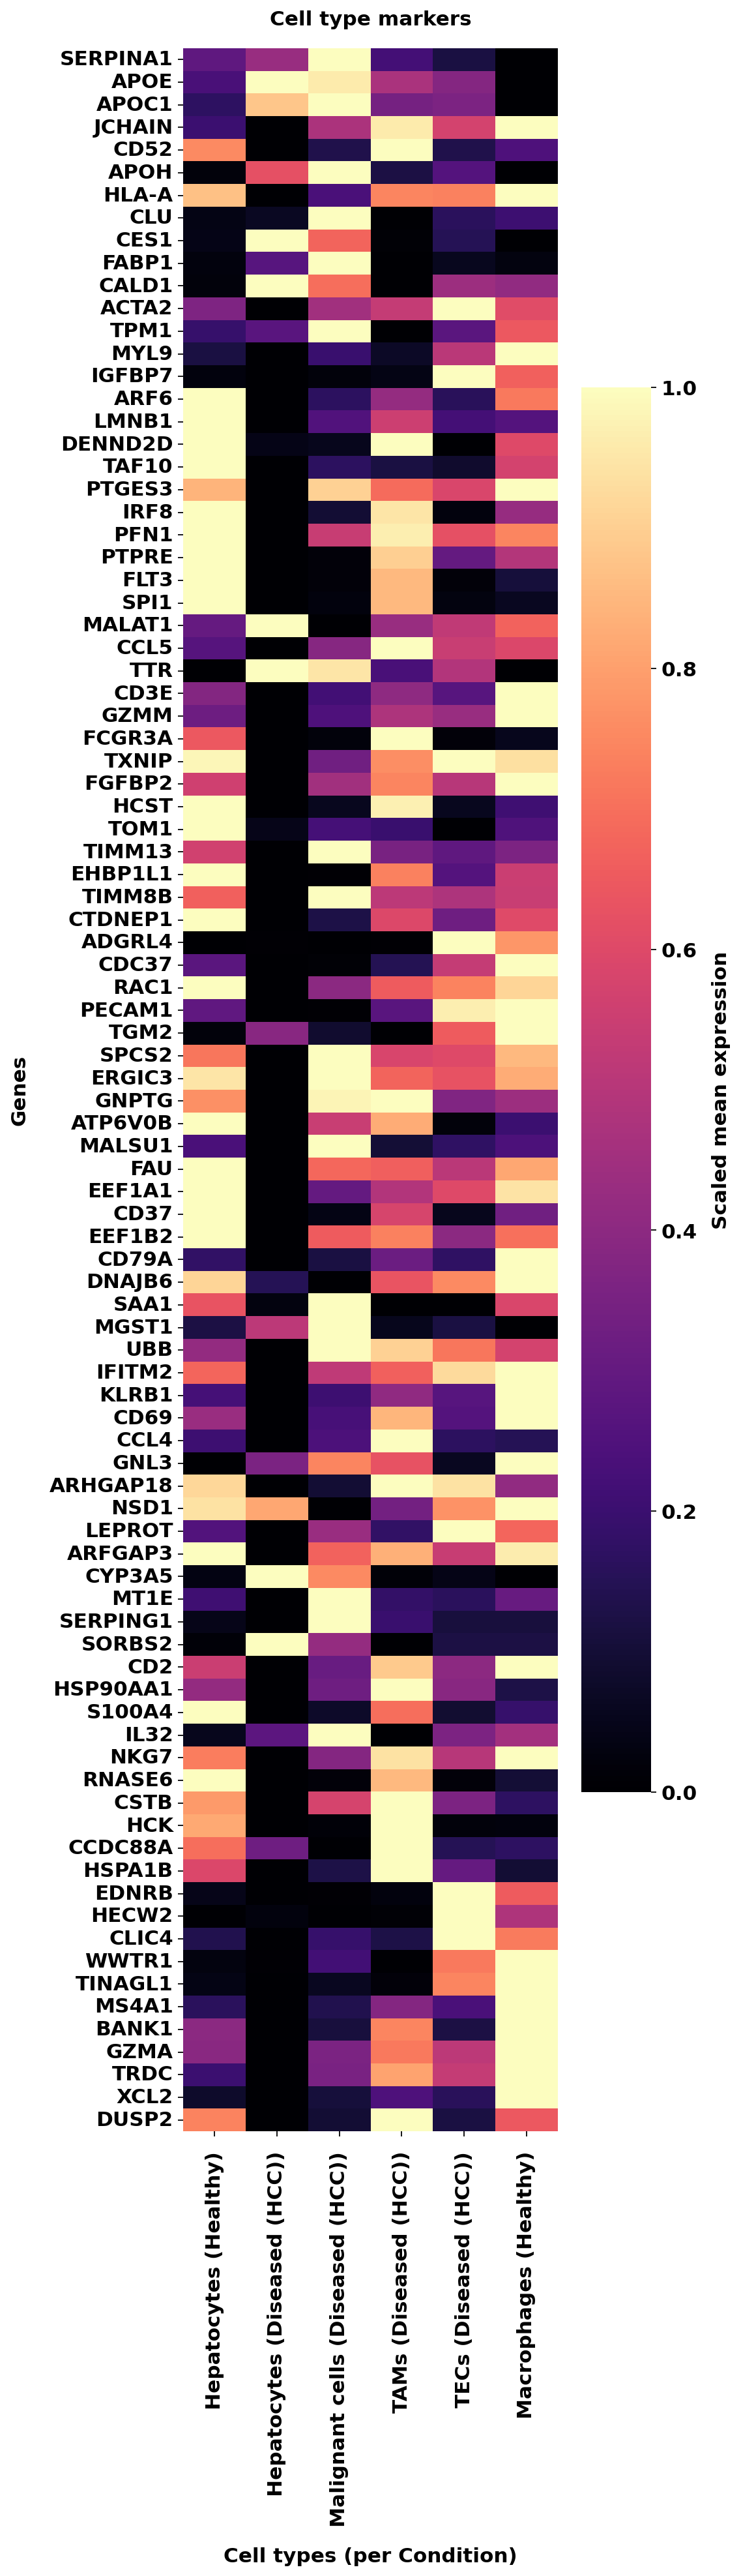

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

M = mean_expr_sub_scaled   # o mean_expr_sub si prefieres sin escalar
out_png = "/home/mdiaz/HCC_project/MERGED_analysis/figures/heatmap_celltype_markers_SELECTED_clean.png"

# Opcional: evita suavizado que produce líneas en algunos backends
mpl.rcParams['image.interpolation'] = 'nearest'

fig, ax = plt.subplots(figsize=(6.8, max(6, 0.35 * len(M))))

hm = sns.heatmap(
    M,
    ax=ax,
    cmap="magma",
    cbar_kws={"label": "Scaled mean expression"},
    xticklabels=True,
    yticklabels=True,
    linewidths=0,          # sin rejilla
    linecolor=None,        # evita líneas
    square=False
)

# ----- ELIMINAR LÍNEAS BLANCAS (artefactos) -----
# QuadMesh del heatmap
mesh = ax.collections[0]
mesh.set_edgecolor('face')   # bordes = color de la cara
mesh.set_linewidth(0.0)      # sin grosor de borde
mesh.set_antialiased(False)  # sin antialias en bordes
mesh.set_rasterized(True)    # rasteriza la malla (también elimina artefactos en PDF/SVG)

# por si el estilo tuviera grid activado
ax.grid(False)

# ----- TEXTO EN NEGRITAS + ALINEACIÓN + ESPACIADO -----
title_txt = "Cell type markers"
ax.set_title(title_txt, fontweight="bold", pad=16)
ax.set_xlabel("Cell types (per Condition)", fontweight="bold", labelpad=14)
ax.set_ylabel("Genes", fontweight="bold", labelpad=14)

# ticks X centrados y con más separación
ax.tick_params(axis="x", labelrotation=90, pad=10)
ax.set_xticklabels(ax.get_xticklabels(), ha="center", va="top", fontweight="bold")
# ticks Y en negrita
ax.set_yticklabels(ax.get_yticklabels(), fontweight="bold")

# colorbar en negrita
cbar = hm.collections[0].colorbar
cbar.set_label("Scaled mean expression", fontweight="bold", labelpad=10)
for l in cbar.ax.get_yticklabels():
    l.set_fontweight("bold")

# quitar spines
for s in ax.spines.values():
    s.set_visible(False)

# Márgenes más generosos para que nada se monte
plt.subplots_adjust(left=0.32, right=0.98, bottom=0.30, top=0.92)

# Guardar a PNG (raster) para evitar artefactos; si necesitas PDF, mantenemos rasterizado el mesh
plt.savefig(out_png, dpi=400, bbox_inches="tight")
print(f"[INFO] Guardado: {out_png}")


# Marcadores únicos por condición 

In [5]:
from matplotlib.ticker import MaxNLocator
import re

# ======== Configuración ========
CELLTYPE_KEY = "CellType_harmonized"
COND_KEY     = "Condition"
HEALTHY      = "Healthy"
DISEASED     = "Diseased (HCC)"
LAYER        = "log1p_norm"   # ya la creaste antes; si no existe, se crea abajo
TOP_N        = 25             # nº de genes a mostrar por panel (tras quitar intersección)
MIN_LOGFC    = 0.25           # mínimo logFC
MAX_QVAL     = 0.05           # p_adj máximo
MIN_PCT_IN   = 0.10           # fracción mínima de células expresando en el grupo
MIN_PCT_OUT  = 0.05           # fracción máxima fuera (opcional; pon None para ignorar)
OUT_PNG      = "/home/mdiaz/HCC_project/MERGED_analysis/figures/unique_markers_condition_ranking.png"

# Filtro suave de housekeeping/mito/ribosomales
remove_patterns = [
    r"^RPL", r"^RPS", r"^MRPL", r"^MRPS",
    r"^MT-", r"^ACTB$", r"^GAPDH$", r"^B2M$", r"^FTL$", r"^FTH1$"
]
regex_remove = re.compile("|".join(remove_patterns), re.IGNORECASE)

# ======== Sanitiza y prepara ========
ad = adata.copy()
ad.obs[COND_KEY] = ad.obs[COND_KEY].astype("category")
ad.obs[CELLTYPE_KEY] = ad.obs[CELLTYPE_KEY].astype("category")

# Mantén solo Healthy / Diseased
ad = ad[ad.obs[COND_KEY].isin([HEALTHY, DISEASED])].copy()
ad.obs[COND_KEY] = ad.obs[COND_KEY].cat.set_categories([HEALTHY, DISEASED], ordered=True)

# Capa log-normalizada si falta
if LAYER not in ad.layers:
    tmp = ad.copy()
    sc.pp.normalize_total(tmp, target_sum=1e4)
    sc.pp.log1p(tmp)
    ad.layers[LAYER] = tmp.X
    del tmp

# ======== Helpers ========
def run_rgg_condition(ad, focus_group, reference_group):
    """rank_genes_groups para Condition: focus_group vs reference_group."""
    key = f"rgg_{focus_group}_vs_{reference_group}"
    sc.tl.rank_genes_groups(
        ad, groupby=COND_KEY, groups=[focus_group], reference=reference_group,
        method="wilcoxon", layer=LAYER, key_added=key
    )
    df = sc.get.rank_genes_groups_df(ad, group=focus_group, key=key)
    # Añade % in/out
    # Scanpy no lo agrega por defecto; estimamos pct_in/pct_out sobre binarizado >0
    X = ad.layers[LAYER] if LAYER in ad.layers else ad.X
    X = X.toarray() if hasattr(X, "toarray") else X
    expr = (X > 0).astype(float)
    mask_in  = (ad.obs[COND_KEY].values == focus_group)
    mask_out = (ad.obs[COND_KEY].values == reference_group)
    pct_in   = expr[mask_in, :].mean(0)
    pct_out  = expr[mask_out,:].mean(0)
    df = df.merge(
        pd.DataFrame({
            "names": ad.var_names,
            "pct_in":  pct_in,
            "pct_out": pct_out,
        }),
        on="names", how="left"
    )
    return df

def filter_df(df):
    """Aplica filtros de HK/mito/ribo, qval, logFC, y pct_in/out."""
    keep = (~df["names"].str.match(regex_remove)) \
           & (df["pvals_adj"].fillna(1.0) <= MAX_QVAL) \
           & (df["logfoldchanges"].fillna(0.0) >= MIN_LOGFC) \
           & (df["pct_in"].fillna(0.0) >= MIN_PCT_IN)
    if MIN_PCT_OUT is not None:
        keep &= (df["pct_out"].fillna(1.0) <= MIN_PCT_OUT)
    df = df.loc[keep].copy()
    # Ordena por score (mayor mejor); si no hay, por p_adj
    if "scores" in df.columns and df["scores"].notna().any():
        df = df.sort_values("scores", ascending=False)
    else:
        df = df.sort_values("pvals_adj", ascending=True)
        # crea un "score" sintético para graficar
        df["scores"] = -np.log10(df["pvals_adj"].clip(lower=1e-300))
    return df

def unique_markers(df_a, df_b):
    """Quita intersección de genes entre ambos y devuelve TOP_N únicos de cada lado."""
    set_b = set(df_b["names"].tolist())
    only_a = df_a.loc[~df_a["names"].isin(set_b)].copy()
    only_b = df_b.loc[~df_b["names"].isin(set(df_a["names"].tolist()))].copy()
    return only_a.head(TOP_N), only_b.head(TOP_N)

def plot_two_panels(df_left, title_left, df_right, title_right, out_png):
    """Figura estilo 'ranking vs score' con anotaciones."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    for ax, df, title in [(axes[0], df_left, title_left), (axes[1], df_right, title_right)]:
        df = df.reset_index(drop=True).copy()
        df["ranking"] = np.arange(1, len(df)+1)
        ax.scatter(df["ranking"], df["scores"])
        for _, r in df.iterrows():
            ax.text(r["ranking"], r["scores"], str(r["names"]),
                    ha="left", va="center", fontsize=8)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("ranking", fontweight="bold")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].set_ylabel("score", fontweight="bold")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"[INFO] Figura guardada en: {out_png}")

# ======== 1) DE en ambas direcciones ========
df_hcc_vs_healthy = run_rgg_condition(ad, DISEASED, HEALTHY)
df_healthy_vs_hcc = run_rgg_condition(ad, HEALTHY, DISEASED)

# ======== 2) Filtros ========
df_hcc_vs_healthy_f = filter_df(df_hcc_vs_healthy)
df_healthy_vs_hcc_f = filter_df(df_healthy_vs_hcc)

# ======== 3) Quitar intersección y seleccionar TOP ========
uniq_hcc, uniq_healthy = unique_markers(df_hcc_vs_healthy_f, df_healthy_vs_hcc_f)

print("[INFO] Únicos HCC:", uniq_hcc["names"].tolist())
print("[INFO] Únicos Healthy:", uniq_healthy["names"].tolist())

# ======== 4) Plot de dos paneles ========
plot_two_panels(
    uniq_hcc,    "Diseased (HCC) vs. rest",
    uniq_healthy,"Healthy vs. rest",
    OUT_PNG
)


normalizing counts per cell
    finished (0:00:05)
ranking genes
    finished (0:11:17)
ranking genes
    finished (0:10:59)
[INFO] Únicos HCC: ['SNHG5', 'SNHG6', 'IGHG4', 'GAS5', 'IGHG1', 'IGHG3', 'CXCL8', 'ZCCHC6', 'TM4SF4', 'OIP5-AS1', 'CTAGE5', 'LINC01578', 'PCED1B-AS1', 'IL1B', 'MGEA5', 'NRP1', 'SNHG16', 'ZCCHC11', 'C1orf54', 'MSR1', 'BEX3', 'PYGL', 'HEIH', 'BX284668', 'AL590867']
[INFO] Únicos Healthy: ['MTRNR2L12', 'CEMIP2', 'MATK', 'AC044849', 'AC245297-1', 'TENT5C', 'ILF3-DT', 'ALDOA', 'OGA', 'APBA2', 'AC007952', 'MTRNR2L8', 'TXK', 'AC058791', 'CHMP4A', 'AC026979-1', 'PRR7', 'PTGDR', 'PILRB', 'TUT4', 'CDK5RAP3', 'POLR2J3-1', 'TBX21', 'ZAP70', 'C1orf56']
[INFO] Figura guardada en: /home/mdiaz/HCC_project/MERGED_analysis/figures/unique_markers_condition_ranking.png


In [6]:
def make_dotplot_df(adata, genes, cond_key="Condition", groups=("Healthy","Diseased (HCC)"), layer="log1p_norm"):
    import numpy as np, pandas as pd
    from scipy import sparse as sp

    ad = adata[adata.obs[cond_key].isin(groups)].copy()
    ad.obs[cond_key] = ad.obs[cond_key].astype("category").cat.set_categories(list(groups), ordered=True)

    X = ad.layers[layer] if layer in ad.layers else ad.X
    if sp.issparse(X): X = X.toarray()

    genes = [g for g in genes if g in ad.var_names]
    gidx = ad.var_names.get_indexer(genes)
    masks = {g: (ad.obs[cond_key].values == g) for g in groups}

    rows = []
    for gi, g in zip(gidx, genes):
        gx = X[:, gi]
        for grp in groups:
            vals = gx[masks[grp]]
            rows.append({
                "gene": g, "group": grp,
                "mean": float(np.mean(vals)) if vals.size else np.nan,
                "pct":  float(np.mean(vals > 0)) if vals.size else np.nan
            })
    df = pd.DataFrame(rows)
    df["mean_scaled"] = df.groupby("gene")["mean"].transform(lambda s: (s - s.min())/(s.max()-s.min()+1e-9))
    return df


In [7]:
genes_plot = uniq_hcc["names"].tolist() + uniq_healthy["names"].tolist()
GROUPS_ORDER = ["Healthy", "Diseased (HCC)"]
df = make_dotplot_df(adata, genes_plot, cond_key=COND_KEY, groups=GROUPS_ORDER, layer=LAYER)

In [8]:
import numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import Normalize

GROUPS_ORDER = ["Healthy", "Diseased (HCC)"]
OUT_PNG = "/home/mdiaz/HCC_project/MERGED_adata/figures/dotplot_unique_markers_split2_clean.png"

# Asegura mean_scaled (0–1 por gen) si no existe:
if "mean_scaled" not in df.columns:
    df["mean_scaled"] = df.groupby("gene")["mean"].transform(
        lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9)
    )

# Orden y split de genes
genes_all = list(dict.fromkeys(df["gene"].tolist()))[::-1]
mid = (len(genes_all) + 1) // 2
genes_left, genes_right = genes_all[:mid], genes_all[mid:]

def _size_from_pct(p):  # p ∈ [0,1]
    return (np.clip(p, 0, 1) / 0.70) * 420

# Estilos para evitar artefactos
mpl.rcParams['axes.grid'] = False
mpl.rcParams['image.interpolation'] = 'nearest'
mpl.rcParams['savefig.transparent'] = False

# >>>> CORREGIDO: sin coma al final <<<<
fig, axes = plt.subplots(1, 2, figsize=(8.4, max(7, 0.44*mid)), sharex=True)
axes = np.atleast_1d(axes)

def plot_panel(ax, genes_panel):
    d = df[df["gene"].isin(genes_panel)].copy()
    d["gene"]  = pd.Categorical(d["gene"],  categories=genes_panel, ordered=True)
    d["group"] = pd.Categorical(d["group"], categories=GROUPS_ORDER, ordered=True)
    d = d.sort_values(["gene", "group"])

    xpos = {g:i for i,g in enumerate(GROUPS_ORDER)}
    ypos = {g:i for i,g in enumerate(genes_panel)}

    coll = ax.scatter(
        x=d["group"].map(xpos), y=d["gene"].map(ypos),
        s=_size_from_pct(d["pct"].values),
        c=d["mean_scaled"].values, cmap="coolwarm", vmin=0, vmax=1,
        edgecolors='none', linewidths=0.0
    )
    # Evitar “cruces”/líneas blancas:
    coll.set_rasterized(True)
    try: coll.set_antialiaseds(False)
    except Exception: pass

    ax.set_xticks([0, 1], GROUPS_ORDER, fontweight="bold")
    ax.tick_params(axis="x", labelrotation=90, pad=6)   # gira 90°
    ax.set_yticks(list(ypos.values()), list(ypos.keys()), fontweight="bold")
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, len(genes_panel)-0.5)
    for s in ax.spines.values(): s.set_linewidth(1.6)

plot_panel(axes[0], genes_left)
plot_panel(axes[1], genes_right)

# Colorbar a la derecha
norm = Normalize(vmin=0.0, vmax=1.0)
sm = mpl.cm.ScalarMappable(cmap="coolwarm", norm=norm)
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), location="right",
                    fraction=0.045, pad=0.08)
cbar.set_label("Mean expression in group", fontweight="bold")

# Leyenda de tamaños fuera
handles = [axes[1].scatter([], [], s=_size_from_pct(p), c="lightgray", edgecolors='none')
           for p in [0.10, 0.30, 0.50, 0.70]]
leg = fig.legend(handles, ["10","30","50","70"],
                 title="Fraction of\ncells in group (%)",
                 loc="upper left", bbox_to_anchor=(0.87, 0.98), frameon=True)
plt.setp(leg.get_title(), fontweight="bold")
for t in leg.get_texts(): t.set_fontweight("bold")

fig.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])
fig.savefig(OUT_PNG, dpi=400, bbox_inches="tight", facecolor="white")
plt.close(fig)
print(f"[INFO] Guardado: {OUT_PNG}")


[INFO] Guardado: /home/mdiaz/HCC_project/MERGED_adata/figures/dotplot_unique_markers_split2_clean.png


In [9]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy import sparse as sp

In [10]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy import sparse as sp

# ===== Parámetros =====
COND_KEY = "Condition"
PAT_KEY  = "Patient"
DISEASED = "Diseased (HCC)"
LAYER    = "log1p_norm"
N_GENES  = 12   # ← ahora 12
OUT_PNG  = "/home/mdiaz/HCC_project/MERGED_adata/figures/violins_top12_uniqHCC_patColors.png"

# Genes: top-12 únicos de HCC ya calculados
genes = [g for g in uniq_hcc["names"].tolist() if g in adata.var_names][:N_GENES]
if not genes:
    raise ValueError("No hay genes válidos en uniq_hcc.")

# Subset SOLO Diseased
ad = adata[adata.obs[COND_KEY] == DISEASED].copy()

# Expresión
X = ad.layers[LAYER] if LAYER in ad.layers else ad.X
if sp.issparse(X):
    X = X.toarray()

# DataFrame largo
gidx = ad.var_names.get_indexer(genes)
expr = pd.DataFrame(X[:, gidx], columns=genes, index=ad.obs_names)
df_long = expr.assign(Patient=ad.obs[PAT_KEY].values).melt(
    id_vars="Patient", var_name="gene", value_name="expr"
)

# Orden estable de pacientes y renombrado (sin "(HCC)")
patients_order = sorted(df_long["Patient"].unique(), key=str)
label_map = {p: f"Patient {i+1}" for i, p in enumerate(patients_order)}
df_long["Patient_label"] = df_long["Patient"].map(label_map)
patients_order_lbl = [label_map[p] for p in patients_order]

# Paleta: un color por paciente
palette_cols = sns.color_palette("tab20", n_colors=len(patients_order_lbl))
palette_map  = dict(zip(patients_order_lbl, palette_cols))

# === Plot ===
sns.set_theme(style="white")

ncols, nrows = 3, 4   # 4 filas × 3 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.9*nrows), sharey=True)
axes = np.ravel(axes)

for i, g in enumerate(genes):
    ax = axes[i]
    d = df_long[df_long["gene"] == g]
    sns.violinplot(
        data=d, x="Patient_label", y="expr",
        order=patients_order_lbl,
        ax=ax, cut=0, inner=None, scale="width",
        palette=palette_map, saturation=1.0
    )
    ax.set_title(g, fontweight="bold")
    ax.set_xlabel("")
    if i % ncols == 0:
        ax.set_ylabel("log1p expression")
    else:
        ax.set_ylabel("")
    # Etiquetas X sin negritas y “corridas” a la izquierda del tick
    ax.tick_params(axis="x", rotation=55, pad=2)
    for t in ax.get_xticklabels():
        t.set_fontweight("normal")
        t.set_ha("right")   # alínea cada etiqueta hacia la izquierda del tick

    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

# Elimina ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Título general
fig.suptitle("Specific gene markers per patient (HCC condition)",
             y=0.995, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.close()
print(f"[INFO] Violines guardados en: {OUT_PNG}")


[INFO] Violines guardados en: /home/mdiaz/HCC_project/MERGED_adata/figures/violins_top12_uniqHCC_patColors.png


In [11]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy import sparse as sp

# ===== Parámetros =====
COND_KEY = "Condition"
PAT_KEY  = "Patient"
DISEASED = "Diseased (HCC)"
LAYER    = "log1p_norm"
N_GENES  = 15   # ← ahora 15
OUT_PNG  = "/home/mdiaz/HCC_project/MERGED_adata/figures/violins_top15_uniqHCC_patColors.png"

# Genes: top-15 únicos de HCC ya calculados
genes = [g for g in uniq_hcc["names"].tolist() if g in adata.var_names][:N_GENES]
if not genes:
    raise ValueError("No hay genes válidos en uniq_hcc.")

# Subset SOLO Diseased
ad = adata[adata.obs[COND_KEY] == DISEASED].copy()

# Expresión
X = ad.layers[LAYER] if LAYER in ad.layers else ad.X
if sp.issparse(X):
    X = X.toarray()

# DataFrame largo
gidx = ad.var_names.get_indexer(genes)
expr = pd.DataFrame(X[:, gidx], columns=genes, index=ad.obs_names)
df_long = expr.assign(Patient=ad.obs[PAT_KEY].values).melt(
    id_vars="Patient", var_name="gene", value_name="expr"
)

# Orden estable de pacientes y renombrado (sin "(HCC)")
patients_order = sorted(df_long["Patient"].unique(), key=str)
label_map = {p: f"Patient {i+1}" for i, p in enumerate(patients_order)}
df_long["Patient_label"] = df_long["Patient"].map(label_map)
patients_order_lbl = [label_map[p] for p in patients_order]

# Paleta: un color por paciente
palette_cols = sns.color_palette("tab20", n_colors=len(patients_order_lbl))
palette_map  = dict(zip(patients_order_lbl, palette_cols))

# === Plot ===
sns.set_theme(style="white")

ncols, nrows = 3, 5   # ← 3 columnas × 5 filas
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.9*nrows), sharey=True)
axes = np.ravel(axes)

for i, g in enumerate(genes):
    ax = axes[i]
    d = df_long[df_long["gene"] == g]
    sns.violinplot(
        data=d, x="Patient_label", y="expr",
        order=patients_order_lbl,
        ax=ax, cut=0, inner=None, scale="width",
        palette=palette_map, saturation=1.0
    )
    ax.set_title(g, fontweight="bold")
    ax.set_xlabel("")
    if i % ncols == 0:
        ax.set_ylabel("log1p expression")
    else:
        ax.set_ylabel("")
    # Etiquetas X sin negritas, ligeramente a la izquierda del tick
    ax.tick_params(axis="x", rotation=55, pad=2)
    for t in ax.get_xticklabels():
        t.set_fontweight("normal")
        t.set_ha("right")
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

# Elimina ejes vacíos si sobran
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Título global (negritas opcional: añade fontweight="bold")
fig.suptitle(
    "Specific gene markers per patient (HCC condition)",
    y=0.995, fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.close()
print(f"[INFO] Violines guardados en: {OUT_PNG}")


[INFO] Violines guardados en: /home/mdiaz/HCC_project/MERGED_adata/figures/violins_top15_uniqHCC_patColors.png
